# Motivation
Ziel des Experiments ist die Untersuchung der Schwingung eines Drehpendels. Dabei wird die Resonanzkurve des Pendels und die Phasenverschiebung zwischen Anregung und Pendelscheibe bei einer Dämpfung gemessen. Die Ergebnisse werden mit theoretischen Werten verglichen.

# Aufgabenstellung
1. Freie Schwingung
    - Messen Sie die freie Schwingung des Drehpendels für zehn verschiedene Dämpfungen.
    - Bestimmen Sie die Frequenz der freien gedämpften Schwingung fd und die Abklingkonstante für jede Messung.
    - Stellen Sie $\omega_d$ als Funktion von $\delta$ graphisch dar und vergleichen Sie mit der Theorie.
2. Resonanzkurve und Phasenverschiebung
    - Messen Sie die Resonanzkurve des Drehpendels, sowie die Phasenverschiebung zwischen Anregung und Pendelscheibe bei einer Dämpfung.
    - Stellen Sie Amplitude und Phase graphisch dar. Bestimmen Sie Resonanzfrequenz und Abklingkonstante durch Fit der theoretischen Kurven an die Daten.
    - Vergleichen Sie die Werte mit den aus der freien Schwingung erhaltenen Werten. Machen Sie Aussagen zur Übereinstimmung.

# Freie Schwingung
## Messen der Daten
Beim Messen der Daten wurde das Drehpendel pro Messung um 90° ausgelenkt und über einen Zeitraum von 20 Sekunden mit einer speziellen Messsoftware aufgezeichnet. DIe Dämpfung des Drehpendes wurde mithilfe zwei Spulen realisiert, somit war die Dämpfung abhängig von der Stromstärke $I$ die durch die Spuelen floss. Die Messungen wurden bei $0.3$ A angefangen und in $0.1$ A Schritten bis $1.2$ A durchgeführt. Da ab $0.5$ A die Dämpfung so stark war, dass die Schwingung nach 10 Skunden nicht mehr vorhaden war, wurde ab $0.5$ A der Zeitraum der Messungen von 20 Sekunden auf 10 verkürzt.

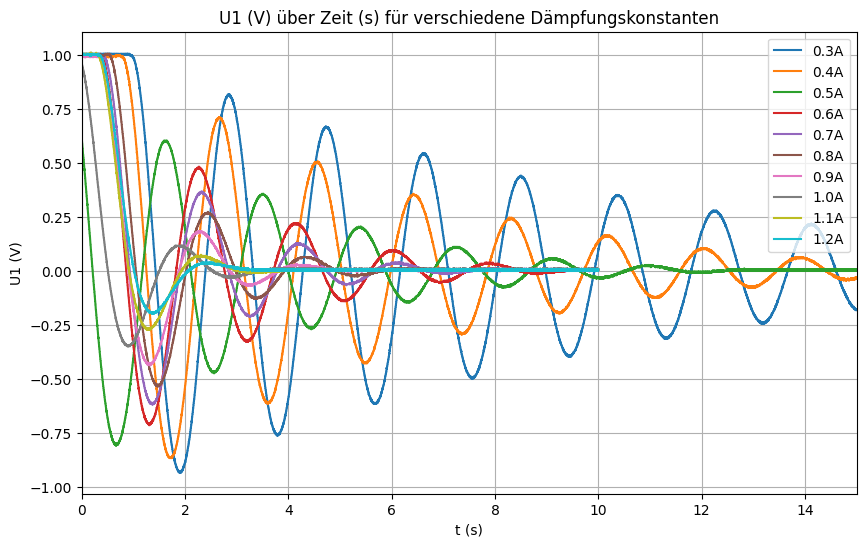

In [30]:
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

plt.figure(figsize=(10, 6))
[plt.plot(data_frames[i]["t (s)"], data_frames[i]["U1(V)"], label=f"{(0.3 + 0.1 * i):.1f}A") for i in range(0, len(data_frames))]
plt.xlim(0, 15)
plt.xlabel("t (s)")
plt.ylabel("U1 (V)")
plt.title("U1 (V) über Zeit (s) für verschiedene Dämpfungskonstanten")
plt.grid()
plt.legend()
plt.show()

## Bestimmung der Frequenz $f_d$ und der Abklingkonstante $\delta$
Um die Frequenz $f_d$ und die Abklingkonstante $\delta$ zu bestimmen, wurde die Schwingung mit der Funktion $A\,e^{-\delta t}\sin(\omega_d t+\phi)+a$ gefittet. Dabei wurde die Frequenz $f_d$ aus der Frequenz $\omega_d$ mit der Formel $f_d = \frac{\omega_d}{2\pi}$ bestimmt. Die Dämpfungskonstante $\delta$ wurde ebenfalls aus dem Fit abgelesen. Zuerst wurden andere Methonden wie die Fouriertransfromation ausprobiert, jedoch lieferte diese Methode zu ungenaue Ergebnisse wie in der nachfolgenden Abbildung zu sehen ist, aufgrund der hohen Dämpfung. Auch andere Methoden wie händisch die Frequenz ausrechnen hatten nicht funktioniert. Weshalb sich am Ende die Curve-Fit Methode als die beste herausgestellt hat. Wie in [Abbildung @fig-plot-fft] zu sehen ist, wird die Däpfungskonstante $\delta$ immer größer je größer die Stromstärke $I$ ist.


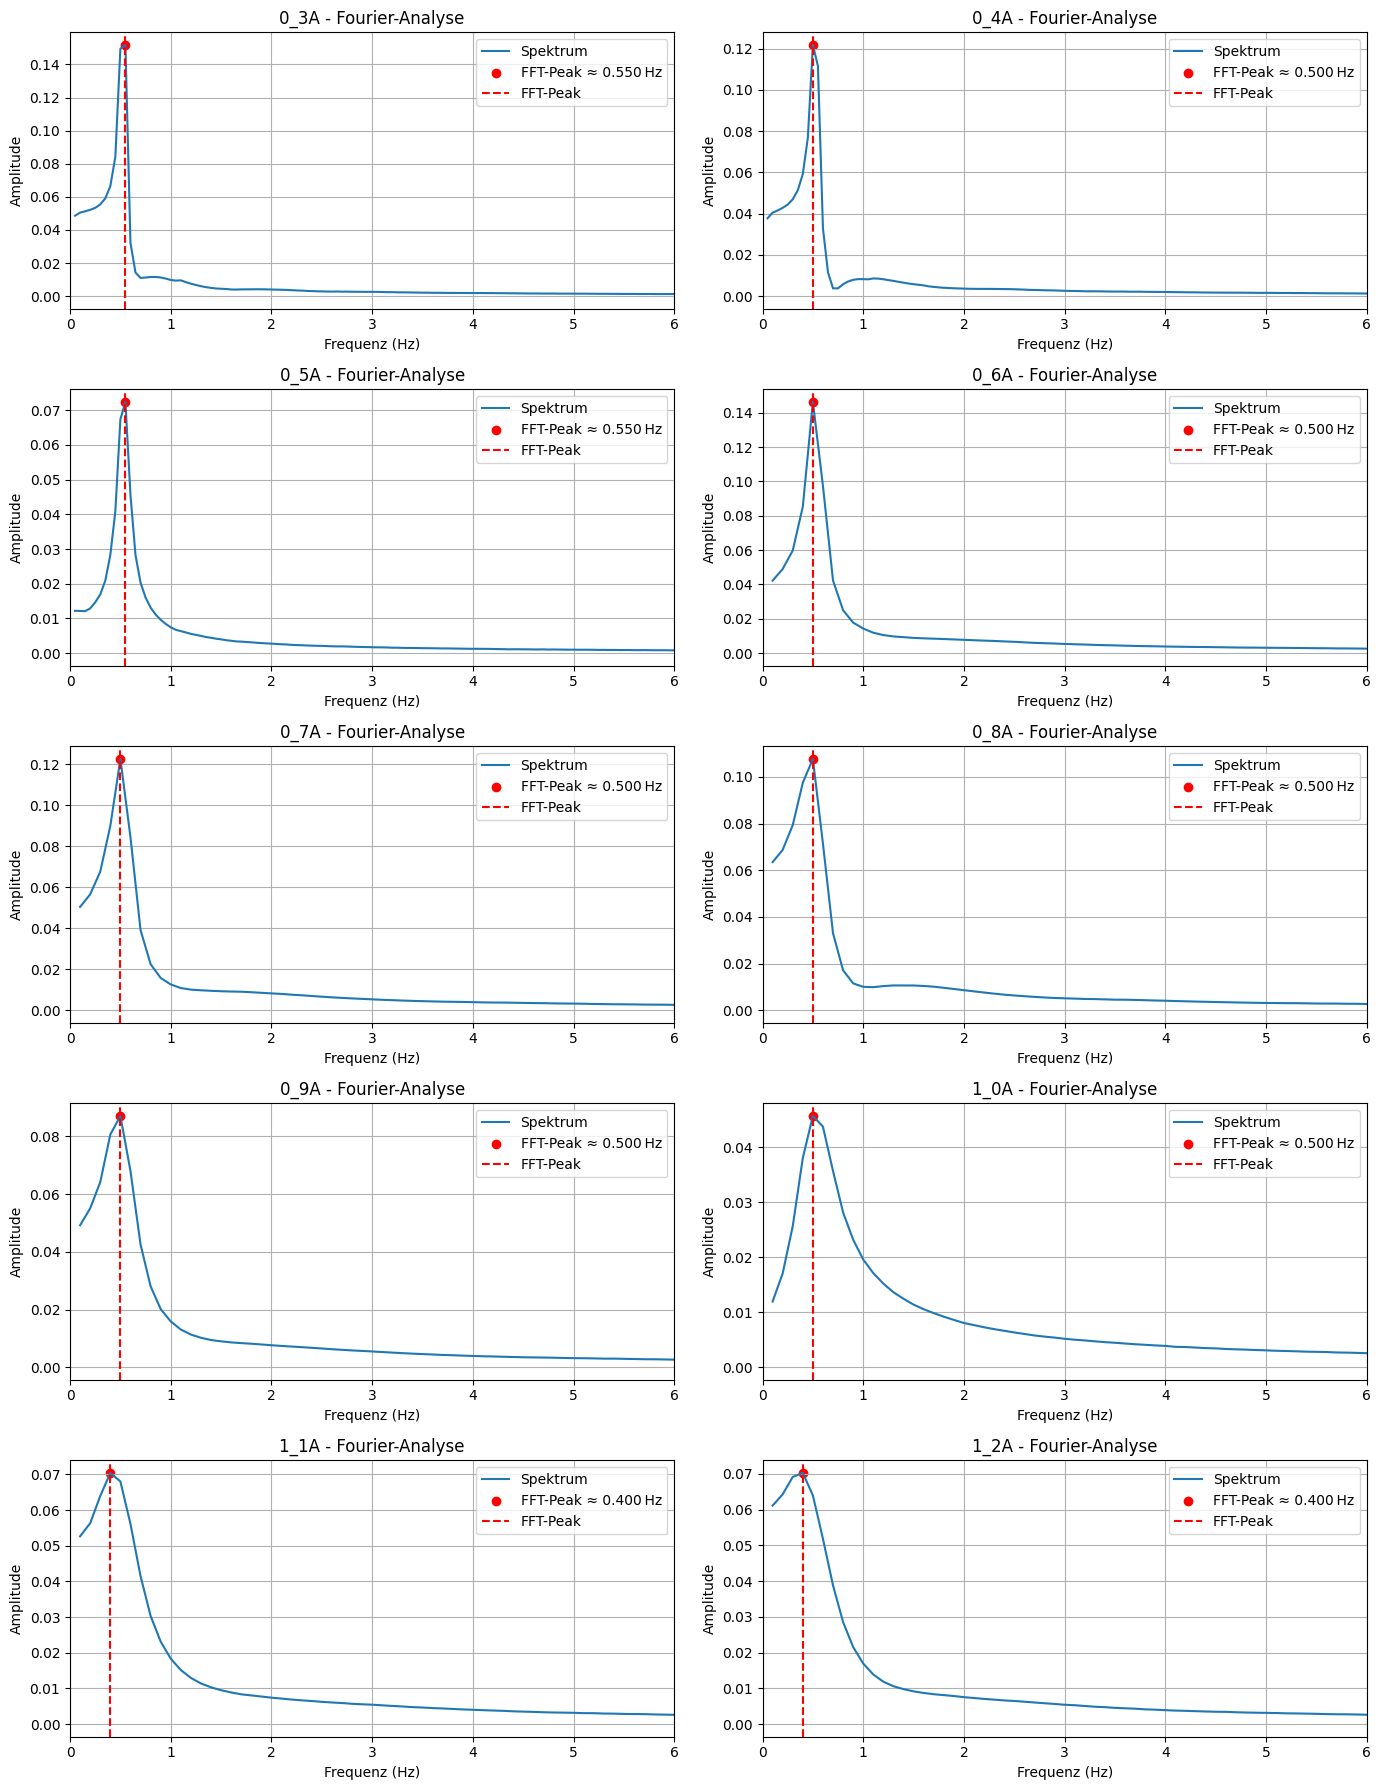

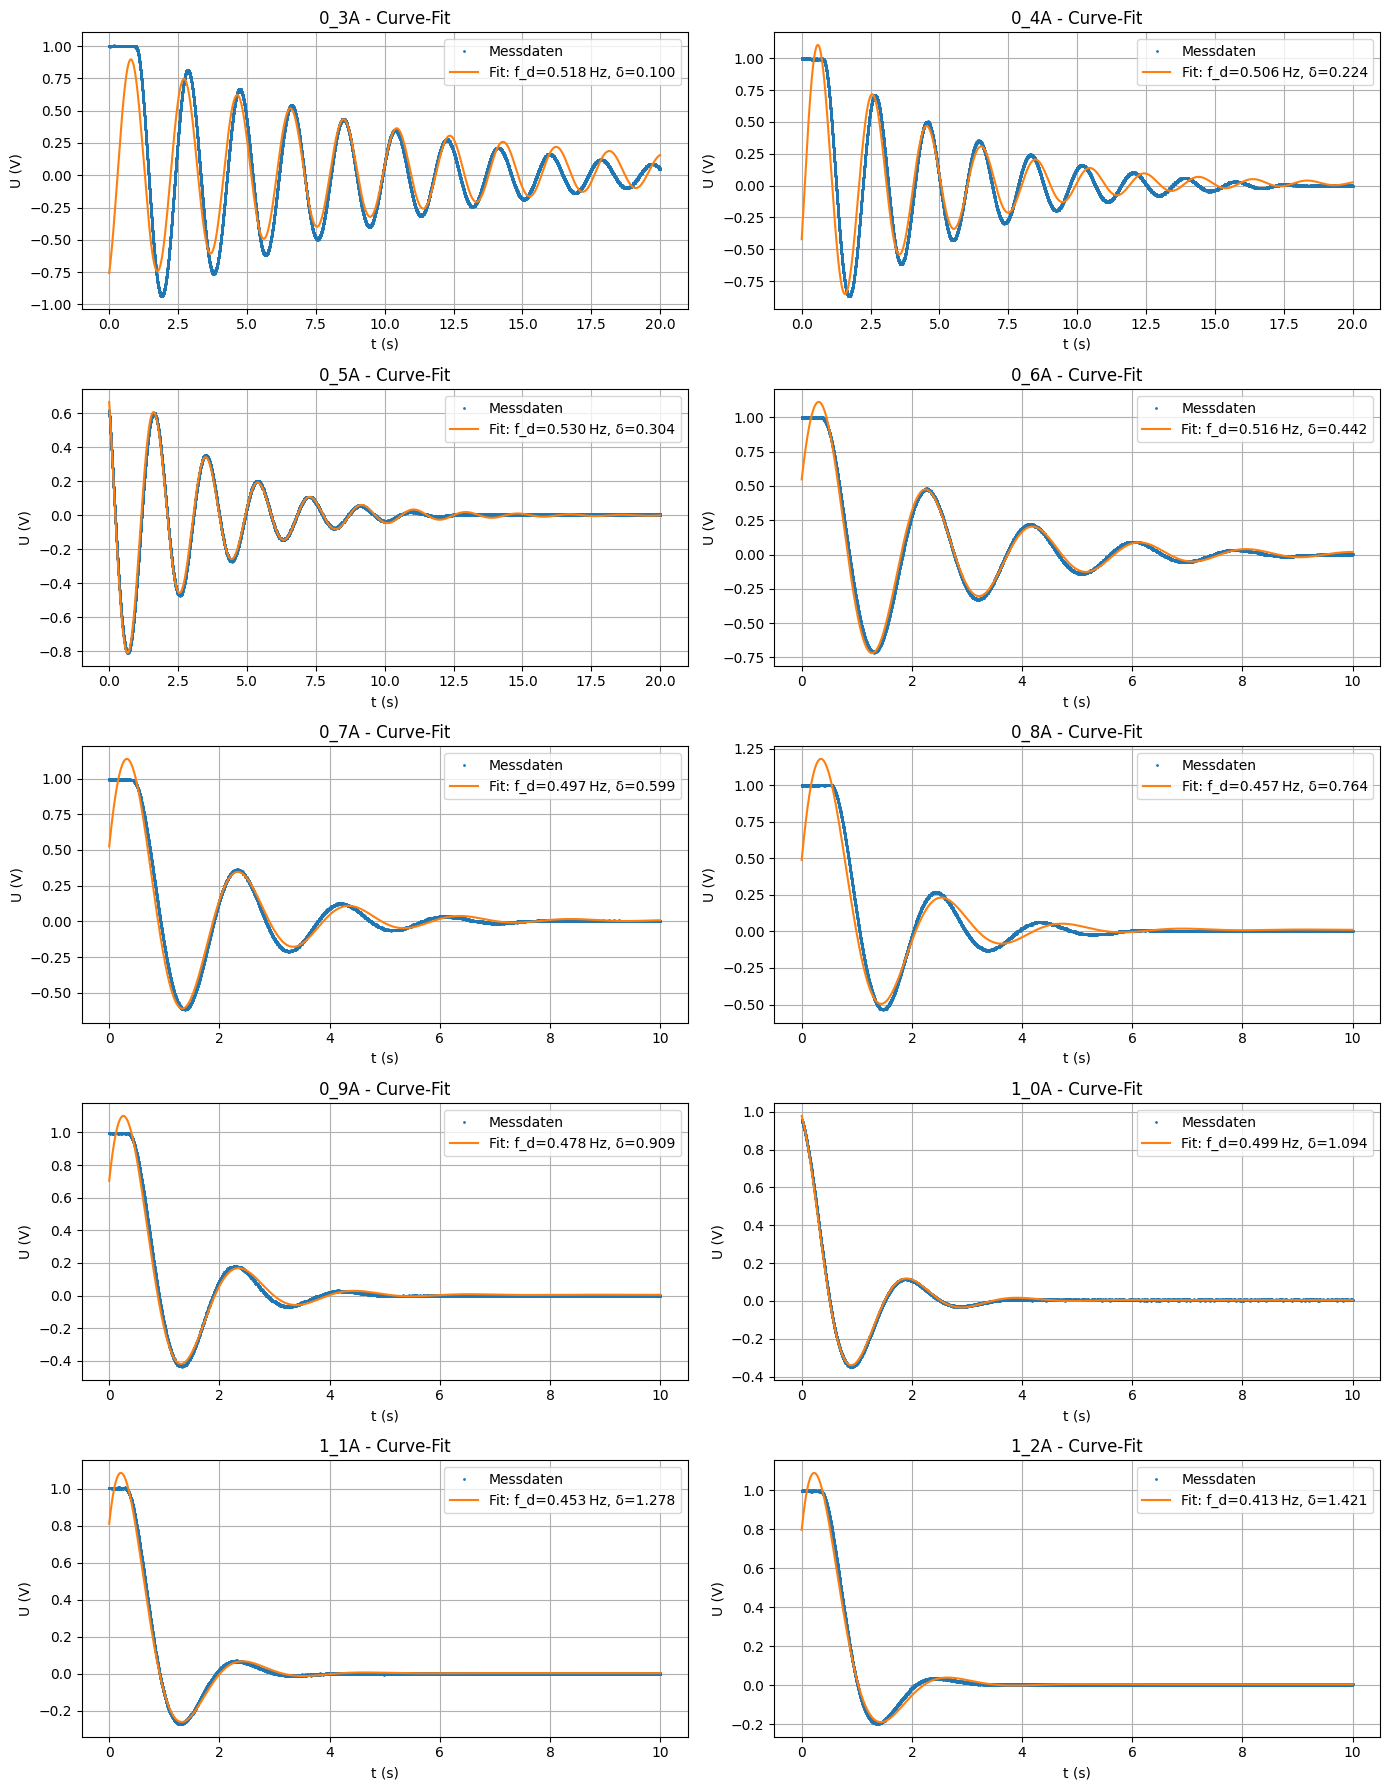

In [31]:
# | label: fig-plot-fft
# | fig-cap: 
# |     - "Fourier-Analyse der Messungen"
# |     - "Curve-Fit an die gedämpfte Sinusfunktion"
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from natsort import natsorted

# ------------------------
# Hilfsfunktionen
# ------------------------

def damped_sinus_function(t, A, delta, omega_d, phase, offset):
    """Gedämpfte Sinusfunktion: A·e^(-delta t)·sin(ω_d t + φ) + offset"""
    return A * np.exp(-delta * t) * np.sin(omega_d * t + phase) + offset

def estimate_omega_fft(t, y):
    """Grobe Abschätzung von ω_d per FFT-Peak"""
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(y - np.mean(y))
    # nur positive Frequenzen betrachten
    mask = f > 0
    f_pos = f[mask]
    Ypos = np.abs(Y[mask])
    idx_peak = np.argmax(Ypos)
    freq_peak = f_pos[idx_peak]
    return 2 * np.pi * freq_peak, freq_peak

def fit_damped_sinus(t, y, omega_guess):
    """Curve‑Fit an die gedämpfte Sinusfunktion"""
    A0     = (np.max(y) - np.min(y)) / 2
    delta0 = 0.1         # Startwert Dämpfung
    phi0   = 0.0
    off0   = np.mean(y)
    p0 = [A0, delta0, omega_guess, phi0, off0]
    
    params, cov = curve_fit(
        damped_sinus_function, t, y,
        p0=p0, maxfev=10_000, 
        bounds=([0, 0,      0,   -2*np.pi, -np.inf],
                [np.inf, np.inf, np.inf, 2*np.pi, np.inf])
    )
    return params, cov

# ------------------------
# Daten einlesen
# ------------------------

folder = "M10_Aufgabe_1_Daten"
# Datei-Liste natur­sor­tiert (0_3, 0_4, …, 1_2)
files = natsorted([f for f in os.listdir(folder) if re.match(r'\d+_\dA_Aufgabe_1_M10.txt', f)])

results = []

# ------------------------
# Plot-Vorbereitung
# ------------------------
fig_fft, axes_fft = plt.subplots(5, 2, figsize=(14, 18))
axes_fft = axes_fft.flatten()

fig_fit, axes_fit = plt.subplots(5, 2, figsize=(14, 18))
axes_fit = axes_fit.flatten()

# ------------------------
# Schleife über alle Dateien
# ------------------------
for idx, fn in enumerate(files):
    # Datei einlesen
    path = os.path.join(folder, fn)
    df = pd.read_csv(path, sep='\t', names=["t", "U"], skiprows=1)
    t = df["t"].values
    U = df["U"].values
    
    # 1) FFT-Analyse
    omega_fft, f_fft = estimate_omega_fft(t, U)
    # Berechne Spektrum für Plot
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(U - np.mean(U))
    mask = f > 0
    f_pos = f[mask]
    amp = np.abs(Y[mask]) / n
    
    # Peak-Markierung
    peaks_idx, _ = find_peaks(amp, height=np.max(amp)*0.1)
    # nur den höchsten Peak auswählen
    main_peak = peaks_idx[np.argmax(amp[peaks_idx])]
    
    # Plot FFT
    ax = axes_fft[idx]
    ax.plot(f_pos, amp, label="Spektrum")
    ax.scatter(f_pos[main_peak], amp[main_peak], color='red',
               label=f"FFT-Peak ≈ {f_pos[main_peak]:.3f} Hz")
    ax.set_xlim(0, 6)
    ax.set_xlabel("Frequenz (Hz)")
    ax.set_ylabel("Amplitude")
    ax.set_title(fn.replace(".txt","")[:4] + " - Fourier-Analyse")
    ax.axvline(f_pos[main_peak], color='red', linestyle='--', label="FFT-Peak")
    ax.legend()
    ax.grid(True)
    
    # 2) Curve‑Fit an gedämpfte Sinusfunktion
    params, cov = fit_damped_sinus(t, U, omega_fft)
    A_fit, delta_fit, omega_d_fit, phi_fit, off_fit = params
    f_d_fit = omega_d_fit / (2*np.pi)
    
    # Plot Fit vs. Daten
    U_fit = damped_sinus_function(t, *params)
    ax2 = axes_fit[idx]
    ax2.plot(t, U, '.', markersize=2, label="Messdaten")
    ax2.plot(t, U_fit, '-', label=f"Fit: f_d={f_d_fit:.3f} Hz, δ={delta_fit:.3f}")
    ax2.set_xlabel("t (s)")
    ax2.set_ylabel("U (V)")
    ax2.set_title(fn.replace(".txt","")[:4] + " - Curve-Fit")
    ax2.legend()
    ax2.grid(True)
    
    # Ergebnis sammeln
    results.append({
        "Stromstärke über Spulen": fn[:4],
        "FFT-Peak [Hz]": f_fft,
        "$f_d$ (Fit) [Hz]": f_d_fit,
        "$\delta$ (Fit) [1/s]": delta_fit,
        "$\omega_d$ (Fit)": omega_d_fit,
    })

# ------------------------
# Layout & Show
# ------------------------
fig_fft.tight_layout()
fig_fit.tight_layout()
plt.show()

### Fehlereinschätzung

Für eine grobe Abschätzung der Fehlerquellen und ‑beträge bei der Bestimmung von $f_d$ und $\delta$:

#### Zeitmessung & Periodendauer

Die Zeitmessung erfolgte mit einer Abtastrate von $1000\,\text{s}^{-1}$, entsprechend einer zeitlichen Auflösung von $\Delta t = 1\,\text{ms}$. Da jeder Messpunkt innerhalb von $\pm 0.5\,\text{ms}$ schwanken kann, ergibt sich für die Bestimmung der Periodendauer $T \approx 2\,\text{s}$ über mehrere Schwingungen (hier: $N = 5$) eine Unsicherheit von:

$$
\sigma_T \approx \sqrt{N} \cdot \Delta t = \sqrt{5} \cdot 0.5\,\text{ms} \approx 1.1\,\text{ms}.
$$

Der relative Fehler beträgt somit:

$$
\frac{\sigma_T}{T} \approx \frac{1.1\,\text{ms}}{2\,\text{s}} \approx 0.055\%.
$$

Da $f_d = \frac{1}{T}$, überträgt sich dieser Fehler auf die Frequenz:


$$
 f_d=\frac1T\approx0{,}5\;\mathrm{Hz}
 \quad\Rightarrow\quad
 \sigma_{f_d}\approx f_d\cdot0.055\%\approx0.0003\;\mathrm{Hz}.
$$


#### Fit an exponentiell gedämpfte Schwingung

Bei der Anpassung der Funktion $A\,e^{-\delta t} \sin(\omega_d t + \phi)$ an verrauschte Daten ist ein konservativer Fehler von **1–2 % auf die Fit-Parameter** realistisch.

Für $f_d \approx 0.50\,\text{Hz}$ ergibt sich dann:

$$
\sigma_{f_d} \approx 0.50\,\text{Hz} \cdot 1.5\% = 0.0075\,\text{Hz} \approx 0.008\,\text{Hz}.
$$

Für den Dämpfungskoeffizienten $\delta \approx 0.10\,\text{s}^{-1}$ ergibt sich bei 2 % Fehler:

$$
\sigma_\delta \approx 0.10\,\text{s}^{-1} \cdot 0.02 = 0.002\,\text{s}^{-1}.
$$

Zusammenfassend ergibt sich für die Fit-Parameter:

$$
f_d = 0.50\,\text{Hz} \pm 0.01\,\text{Hz} \\
\delta = 0.10\,\text{s}^{-1} \pm 0.002\,\text{s}^{-1}
$$

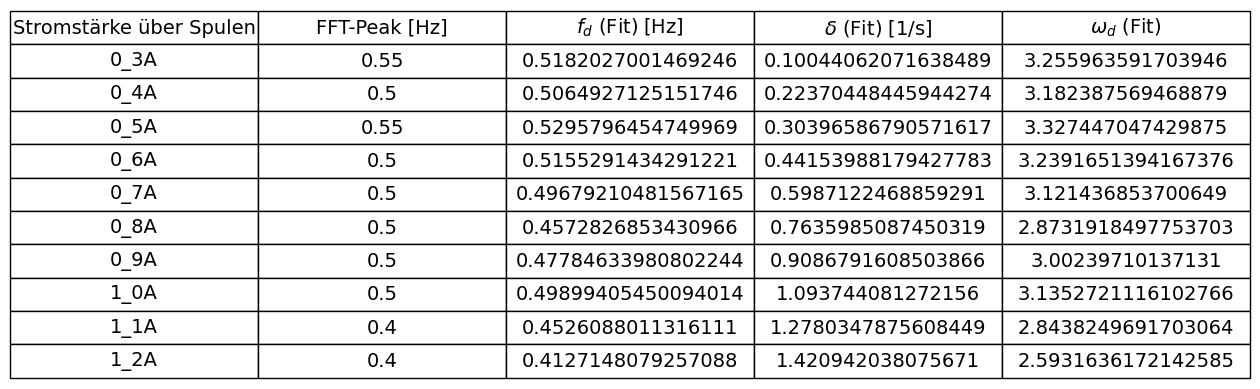

In [32]:
# | label: fig-tab-plot-fft
# | fig-cap: Tabelle der bestimmten Dämpfungskonstanten für die verschiedene Messungen

# ------------------------
# Ausgabe der Ergebnisse
# ------------------------
fig_table, axes_table = plt.subplots()
# hide axes
fig_table.patch.set_visible(False)
axes_table.axis('off')
axes_table.axis('tight')

# Ergebnisse in DataFrame umwandeln
res_df = pd.DataFrame(results)
#print("\nErgebnisse zusammengefasst:")
#print(res_df.to_string(index=False))

# Tabelle mit größerer Schrift und größerem Zellenabstand für bessere Lesbarkeit
table = axes_table.table(
    cellText=res_df.values,
    colLabels=res_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(2.5, 2)  # (width, height) Skalierung der Tabelle

# ------------------------
# Layout & Show
# ------------------------
plt.show()

## $\omega_d$ als Funktion von $\delta$

Bei dieser Aufgabe sollte die Kreisfrequenz $\omega_d$ als Funktion der Abklingkonstante $\delta$ dargestellt werden. Da in den Auswertungs Hinweisen aber auch noch einmal gesagt wurde, dass $\omega_d²$ und $\delta²$ geplottet werden soll, wurde hier beides gemacht.

Die theoretische Beziehung zwischen der gedämpften Eigenfrequenz ωdωd​, der Dämpfung $\delta$, und der ungedämpften Eigenfrequenz $\omega_d$ ergibt sich aus der Schwingungsgleichung eines gedämpften harmonischen Oszillators:
$$\omega_d = \sqrt{\omega_0^2 - \delta^2} \Rightarrow \omega_d^2 = \omega_0^2 - \delta^2$$
So kommen wir für [Abbildung @fig-omega2-over-delta2] auf folgende lineare Beziehung zwischen $\omega_d²$​ und $\delta²$ mit der Steigung $-1$:
$$\omega_d^2 = (-1) \cdot \delta^2 +  \omega_0^2 $$
Während wir für Abbildung @fig-omega2-over-delta2] die orginelle Beziehung $\omega_d = \sqrt{\omega_0^2 - \delta^2}$ gilt.

Die gemessenen Werte von $\omega_d$​ weichen in [Abbildung @fig-omega2-over-delta2] im Mittel um etwa 0.83 rad²/s² von der theoretischen Beziehung $\omega_d^2 = \omega_0^2 - \delta^2$ ab.
Diese Abweichung ist gering im Vergleich zum typischen Wertebereich und kann durch Messfehler erklärt werden. Die lineare Regression ergibt eine Steigung von -1.644 statt −1 was die Theorie vorraus sagt, was darauf hindeutet das die Frequenz $\omega_d$ sinkt schneller mit wachsender Dämpfung $\delta$, als die Theorie vorhersagt. Mögliche Ursachen sind systematische Messfehler, eine nichtlineare Dämpfung im realen System oder eine Vernachlässigung höherer Effekte im theoretischen Modell.

In der [Abbildung @fig-omega-over-delta] das die Messwerte grob an dem theoretischen Wert liegen. Jedoch streuen sie stark je größer die Dämpfung $\delta$ ist. Auch hier könnte eine Vernachlässigung höherer Effekte im theoretischen Modell oder Mess-/Auswerungsfehler eine Rolle spielen.

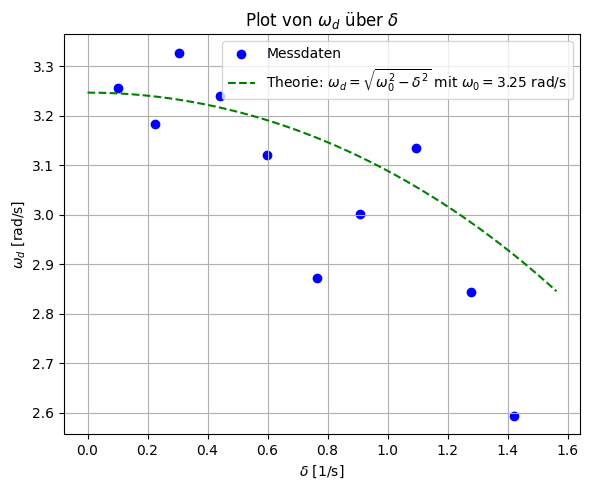

In [33]:
# | label: fig-omega-over-delta
# | fig-cap: Plot von Omega über Delta
import numpy as np
import matplotlib.pyplot as plt

# Daten aus DataFrame
delta = res_df["$\delta$ (Fit) [1/s]"].values
f_d = res_df["$f_d$ (Fit) [Hz]"].values
omega_d = 2 * np.pi * f_d

# Sortieren für saubere Darstellung
sort_idx = np.argsort(delta)
delta_sorted = delta[sort_idx]
omega_d_sorted = omega_d[sort_idx]

# ω₀ schätzen: z. B. aus vorheriger Regression
# Du kannst auch manuell setzen: z. B. ω0 = 12.3
intercept = np.polyfit(delta**2, omega_d**2, 1)[1]
omega_0 = np.sqrt(intercept)

# Theoriekurve: ω_d = sqrt(ω0² - δ²)
delta_theory = np.linspace(0, delta.max()*1.1, 200)
omega_theory = np.sqrt(np.maximum(omega_0**2 - delta_theory**2, 0))  # Schutz vor sqrt(negativ)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(delta, omega_d, label="Messdaten", color="blue")
plt.plot(delta_theory, omega_theory, '--', color="green",
         label=fr"Theorie: $\omega_d = \sqrt{{\omega_0^2 - \delta^2}}$ mit $\omega_0 = {omega_0:.2f}$ rad/s")



plt.xlabel(r"$\delta$ [1/s]")
plt.ylabel(r"$\omega_d$ [rad/s]")
plt.title(r"Plot von $\omega_d$ über $\delta$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


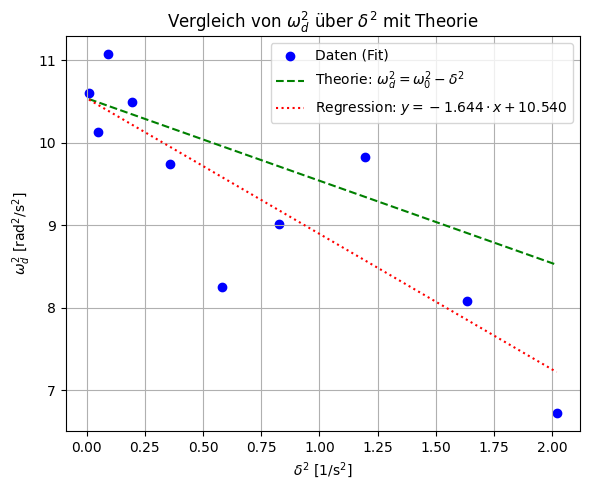

Mittlere quadratische Abweichung (MSE) von der Theorie: 0.82582 rad²/s²


In [34]:
# | label: fig-omega2-over-delta2
# | fig-cap: Plot von Omega² über Delta²
import numpy as np
import matplotlib.pyplot as plt

# Daten
delta = res_df["$\delta$ (Fit) [1/s]"].values
f_d = res_df["$f_d$ (Fit) [Hz]"].values
omega_d = 2 * np.pi * f_d

# Quadrate
delta2 = delta**2
omega2 = omega_d**2

# Lineare Regression
coeffs = np.polyfit(delta2, omega2, 1)
slope, intercept = coeffs  # slope ≠ -1, intercept ≈ ω0² (angenähert)

# Theorie (ω_d^2 = ω_0^2 - δ^2)
omega0_squared = intercept  # aus Regression angenommen
omega2_theory_pts = omega0_squared - delta2
abweichung = omega2 - omega2_theory_pts  # Differenz zu Theorie
mse = np.mean(abweichung**2)

# Theorielinie für den Plot
delta2_lin = np.linspace(delta2.min(), delta2.max(), 100)
omega2_theory = omega0_squared - delta2_lin

# Plot
plt.figure(figsize=(6,5))
plt.scatter(delta2, omega2, label="Daten (Fit)", color="blue")
plt.plot(delta2_lin, omega2_theory, '--', label=r"Theorie: $\omega_d^2 = \omega_0^2 - \delta^2$", color="green")
plt.plot(delta2_lin, slope * delta2_lin + intercept, ':',
         label=fr"Regression: $y = {slope:.3f} \cdot x + {intercept:.3f}$", color="red")

plt.xlabel(r"$\delta^2\ \mathrm{[1/s^2]}$")
plt.ylabel(r"$\omega_d^2\ \mathrm{[rad^2/s^2]}$")
plt.title("Vergleich von $\omega_d^2$ über $\delta^2$ mit Theorie")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ausgabe der Abweichung
print(f"Mittlere quadratische Abweichung (MSE) von der Theorie: {mse:.5f} rad²/s²")


# Aufgabe 2

## Messen der Daten

Bei der zweiten Aufgabe, sollten wir die Resonanzkurve des Drehpendels bei einer Dämpfung messen, sowie die Phasenverschiebung zwischen der Anregung und Pendelscheibe. Da die Dämpfung über die Spule kommt und diese über den Strom am Channel 1 angesteuert wird, haben wir dort konstant 0.3 A eingestellt. Um herauszufinden, in welchem Bereich die Resonanzkurve circa ihren Peak hat, wurde zuerst in 1V Schritten zwischen 3V und 12V gemessen. Dabei ist aufgefallen, dass der Peak ungefähr bei 11V liegt, weshalb die eigentliche Messung zwischen 9V und 12V stattfand jeweils im Abstand von 0.1V.

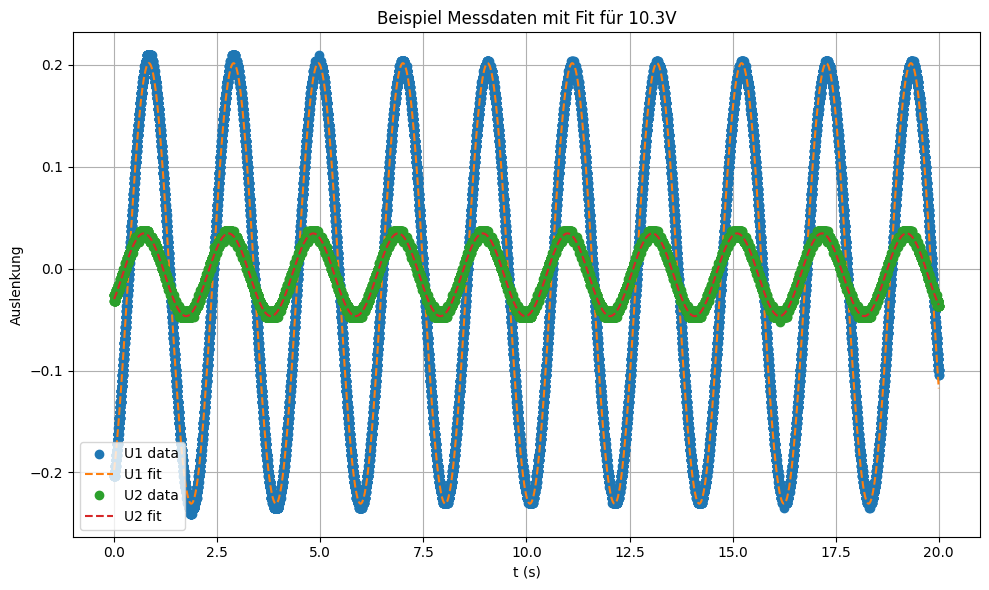

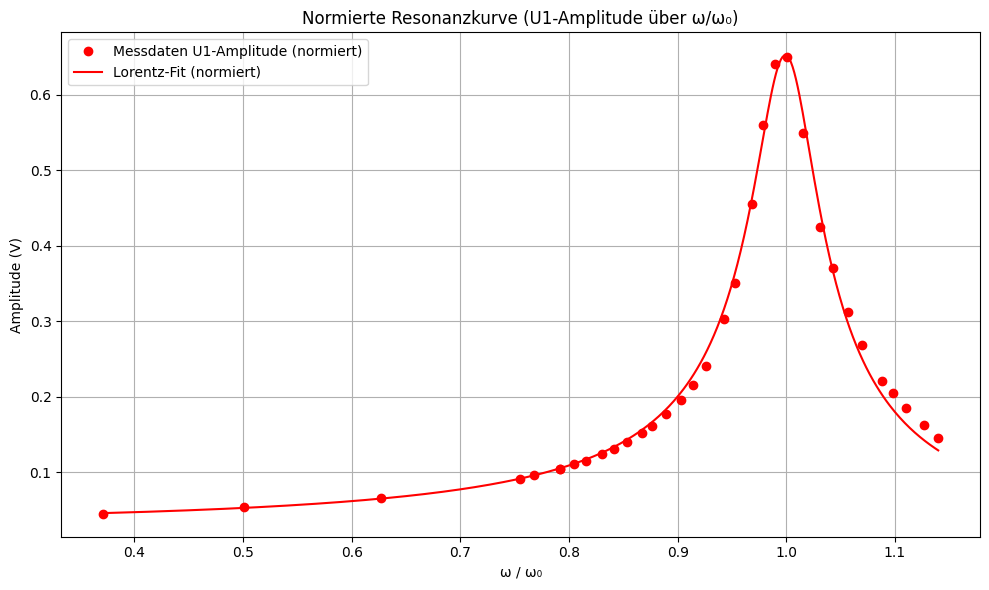

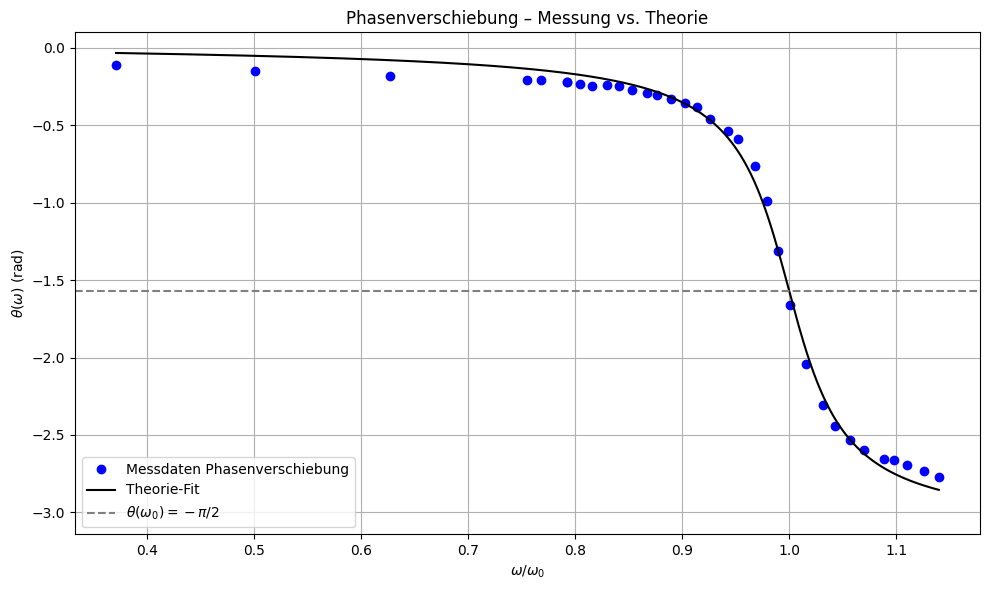

=== Resonanzkurve (U1-Amplitude) ===
A0 (Amplitude bei Resonanz): 0.442978 V
ω₀ (Eigenkreisfrequenz): 3.345119 rad/s
δ (Abklingkonstante): 0.101583 1/s
→ Resonanzfrequenz ω_R = sqrt(ω₀² - 2δ²) = 3.342033 rad/s

=== Phasenverschiebung (θ) ===
δ (Abklingkonstante aus Phase): 0.038729 1/s
→ Wendepunkt der Phase bei ω = ω₀, dort θ = -π/2


In [35]:
# | fig-cap:
# |     - "Beispiel Messdaten mit Fit für 10.3V"
# |     - "Normierte Resonanzkurve (U1-Amplitude über omega/omega_0)"
# |     - "Phasenverschiebung – Messung vs. Theorie"
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted

# Sinusfunktion mit Offset
def sinus_function(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset


# Lorentz-Funktion für Resonanzkurve
def lorentz_func(omega, A0, omega0, beta):
    return A0 / np.sqrt((omega0**2 - omega**2)**2 + (2*beta*omega)**2)


# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, omega_guess, phase_guess, offset_guess]
    params, params_covariance = curve_fit(
        sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    fitted_y = sinus_function(x_data, *params)
    return params, fitted_y

def phase_shift_theory(omega_ratio, beta):
    r = np.array(omega_ratio)
    arg = (2 * beta * r) / (1 - r**2)
    theta = np.arctan(arg)
    # +π für r > 1, um Sprung zu vermeiden
    theta = np.where(r > 1, theta + np.pi, theta)
    theta = np.where(np.isclose(r, 1.0), np.pi/2, theta)
    return -theta


# Ordnerpfad anpassen
filepath = "M10_Aufgabe_2_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
amplitudes_U2 = []
omegas_U2 = []
delta_t = []
phasen_diff = []
params_U1_Example = []
params_U2_Example = []
fitted_U1_Example = []
fitted_U2_Example = []
x_Example = 0
y_Example = 0
z_Example = 0

for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['t (s)', 'U1(V)', 'U2(V)']

    x = df['t (s)'].values
    y = df['U1(V)'].values
    z = df['U2(V)'].values

    if '10_3V_Aufgabe_2_daten.csv' in filename:
        paramsU2, fitted_U2 = fit_sinus(x, z)
        paramsU1 = [0.216, 3.06, -1.01, -0.0146]
        fitted_U1 = sinus_function(x, *paramsU1)
        params_U1_Example = paramsU1
        fitted_U1_Example = fitted_U1
        params_U2_Example = paramsU2
        fitted_U2_Example = fitted_U2
        x_Example = x
        y_Example = y
        z_Example = z
    else:
        paramsU1, fitted_U1 = fit_sinus(x, y)
        paramsU2, fitted_U2 = fit_sinus(x, z)

    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[1])
    amplitudes_U2.append(np.abs(paramsU2[0]))
    omegas_U2.append(paramsU2[1])


    # Fit-Parameter
    A1, omega1, phi1, _ = paramsU1
    A2, omega2, phi2, _ = paramsU2

    # Periodendauer (Durchschnitt)
    T = 2 * np.pi / ((omega1 + omega2) / 2)

    # t_max berechnen (nur für 1. Periode ab t=0)
    t_max_U1 = ((np.pi / 2) if A1 > 0 else (3 * np.pi / 2)) - phi1
    t_max_U1 = t_max_U1 / omega1 % T

    t_max_U2 = ((np.pi / 2) if A2 > 0 else (3 * np.pi / 2)) - phi2
    t_max_U2 = t_max_U2 / omega2 % T

    # Delta-t auf Bereich [-T/2, +T/2] bringen:
    delta = t_max_U2 - t_max_U1
    if delta > T/2:
        delta -= T
    elif delta < -T/2:
        delta += T

    delta_t.append(delta)

    phasen_dif = omega1 * delta
    phasen_diff.append(phasen_dif)

    #plt.figure(figsize=(10, 6))
    #plt.plot(x, y, 'o', label='U1 data')
    #plt.plot(x, fitted_U1, '--', label='U1 fit')
    #plt.plot(x, z, 'o', label='U2 data')
    #plt.plot(x, fitted_U2, '--', label='U2 fit')
    #plt.xlabel('t (s)')
    #plt.ylabel('Auslenkung')
    #plt.title(filename)
    #plt.legend()
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

    


# Plotten
plt.figure(figsize=(10, 6))
plt.plot(x_Example, y_Example, 'o', label='U1 data')
plt.plot(x_Example, fitted_U1_Example, '--', label='U1 fit')
plt.plot(x_Example, z_Example, 'o', label='U2 data')
plt.plot(x_Example, fitted_U2_Example, '--', label='U2 fit')
plt.xlabel('t (s)')
plt.ylabel('Auslenkung')
plt.title('Beispiel Messdaten mit Fit für 10.3V')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Arrays und Sortierung
omegas_U2 = np.array(omegas_U2)
amplitudes_U1 = np.array(amplitudes_U1)
sorted_indices = np.argsort(omegas_U2)
omegas_U2 = omegas_U2[sorted_indices]
amplitudes_U1 = amplitudes_U1[sorted_indices]
delta_t = np.array(delta_t)[sorted_indices]
delta_t = - delta_t  # Vorzeichen umkehren
phasen_diff = np.array(phasen_diff)[sorted_indices]

# Fit der Resonanzkurve U1
p0_amp = [np.max(amplitudes_U1), omegas_U2[np.argmax(amplitudes_U1)], 0.1]
params_amp, _ = curve_fit(lorentz_func, omegas_U2, amplitudes_U1, p0=p0_amp, maxfev=10000)

fit_omegas = np.linspace(np.min(omegas_U2), np.max(omegas_U2), 500)
fit_amplitudes = lorentz_func(fit_omegas, *params_amp)


# Normierte x-Werte
omega0 = params_amp[1]
beta = params_amp[2]

omega_ratio_data = omegas_U2 / omega0
omega_ratio_fit = fit_omegas / omega0




p0_phase = [beta]  # Startwert aus dem Lorentz-Fit
params_phase, _ = curve_fit(
    phase_shift_theory,
    omega_ratio_data,
    phasen_diff,
    p0=p0_phase,
    bounds=(0.001, 1.0),
    maxfev=10000
)


plt.figure(figsize=(10, 6))
plt.plot(omega_ratio_data, amplitudes_U1, 'ro', label='Messdaten U1-Amplitude (normiert)')
plt.plot(omega_ratio_fit, fit_amplitudes, 'r-', label='Lorentz-Fit (normiert)')
plt.xlabel('ω / ω₀')
plt.ylabel('Amplitude (V)')
plt.title('Normierte Resonanzkurve (U1-Amplitude über ω/ω₀)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fit_phase_curve = phase_shift_theory(omega_ratio_fit, *params_phase)

plt.figure(figsize=(10, 6))
plt.plot(omega_ratio_data, phasen_diff, 'bo', label='Messdaten Phasenverschiebung')
plt.plot(omega_ratio_fit, fit_phase_curve, 'k-', label='Theorie-Fit')
plt.axhline(-np.pi/2, color='gray', linestyle='--', label=r'$\theta(\omega_0) = -\pi/2$')
plt.xlabel(r'$\omega / \omega_0$')
plt.ylabel(r'$\theta(\omega)$ (rad)')
plt.title('Phasenverschiebung – Messung vs. Theorie')
plt.ylim(-np.pi, 0.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


import math

# Resonanzkurven-Parameter
A0, omega0, beta = params_amp
print("=== Resonanzkurve (U1-Amplitude) ===")
print(f"A0 (Amplitude bei Resonanz): {A0:.6f} V")
print(f"ω₀ (Eigenkreisfrequenz): {omega0:.6f} rad/s")
print(f"δ (Abklingkonstante): {beta:.6f} 1/s")
print(f"→ Resonanzfrequenz ω_R = sqrt(ω₀² - 2δ²) = {math.sqrt(omega0**2 - 2 * beta**2):.6f} rad/s")

# Phasenverschiebung-Parameter
delta_phase = params_phase[0]
print("\n=== Phasenverschiebung (θ) ===")
print(f"δ (Abklingkonstante aus Phase): {delta_phase:.6f} 1/s")
print("→ Wendepunkt der Phase bei ω = ω₀, dort θ = -π/2")



Alle 30 Datensätze können als Plot angegeben werden und für alle wurde eine Fit-Funktion gefunden, allerdings wurde aus Platzgründen nur ein Beispiel im Protkoll angezeigt. Resonanzkurve und Phasenverschiebung wurden ebenfalls geplotet und als Bild angehängt, wobei die Parameter für die Fitfunktion dazu ausgeben wurden.

# Schlussfolgerung
Zusammenfassend lässt sich sagen, dass die Resonanzkurve und die Phasenverschiebung des Drehpendels erfolgreich gemessen wurden. Die Ergebnisse stimmen relativ gut mit den theoretischen Werten überein. Die Abweichungen können durch Messfehler oder systematische Fehler erklärt werden.